# Getting started

I'm using this notebook to get started with starsim. It will contain my take on the basic tutorials, and I'm hoping to establish a good workflow.

My model for this self-documentation is Wes's work on multiscale polio. It serves as both good living documentation and useful interaction with the code.



—————————————
Running demo:
—————————————

Initializing sim with 10000 agents
  Running 2000.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 2010.0 (10/51) (0.04 s)  ••••———————————————— 22%
  Running 2020.0 (20/51) (0.08 s)  ••••••••———————————— 41%
  Running 2030.0 (30/51) (0.11 s)  ••••••••••••———————— 61%
  Running 2040.0 (40/51) (0.14 s)  ••••••••••••••••———— 80%
  Running 2050.0 (50/51) (0.16 s)  •••••••••••••••••••• 100%



——————————
Results:
——————————

#0. 'randomnet_n_edges':  49611.666666666664
#1. 'sir_n_susceptible':  1154.6274509803923
#2. 'sir_n_infected':     1270.1764705882354
#3. 'sir_n_recovered':    7495.490196078431
#4. 'sir_prevalence':     0.12732202802759224
#5. 'sir_new_infections': 195.4313725490196
#6. 'sir_cum_infections': 9967.0
#7. 'n_alive':            9920.29411764706
#8. 'new_deaths':         2.0392156862745097
#9. 'cum_deaths':         104.0
Figure(800x600)


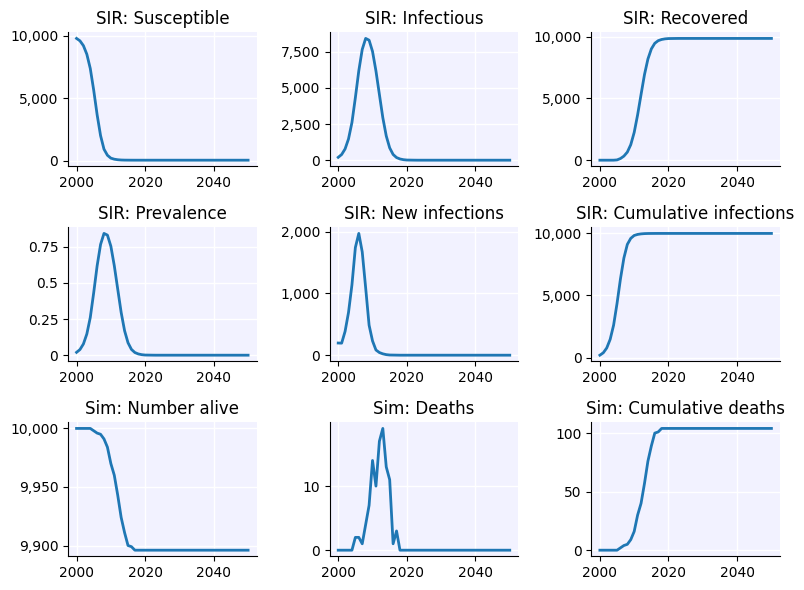

Sim(n=10000; 2000—2050; networks=randomnet; diseases=sir)

In [3]:
# simple demo
import starsim as ss
ss.demo()

Initializing sim with 5000 agents
  Running 2000.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 2010.0 (10/51) (0.03 s)  ••••———————————————— 22%
  Running 2020.0 (20/51) (0.05 s)  ••••••••———————————— 41%
  Running 2030.0 (30/51) (0.07 s)  ••••••••••••———————— 61%
  Running 2040.0 (40/51) (0.09 s)  ••••••••••••••••———— 80%
  Running 2050.0 (50/51) (0.11 s)  •••••••••••••••••••• 100%

Figure(800x600)


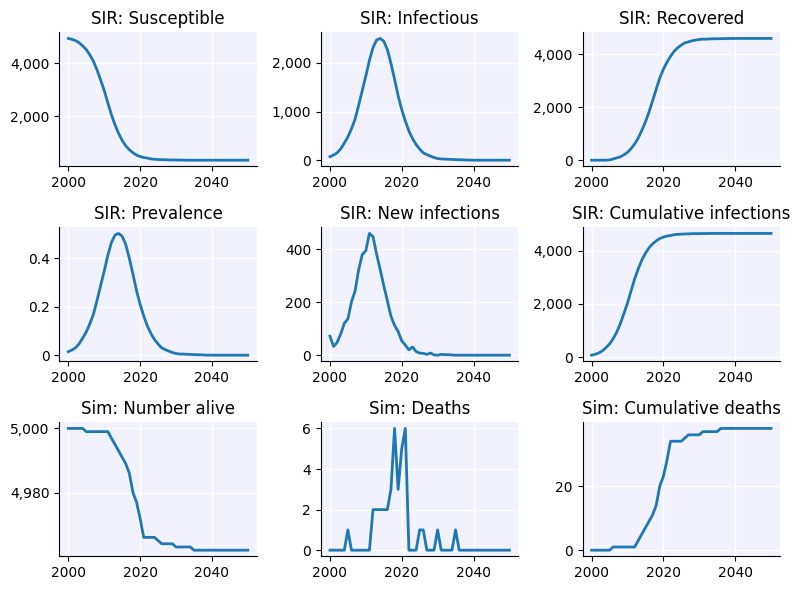

Figure(640x480)


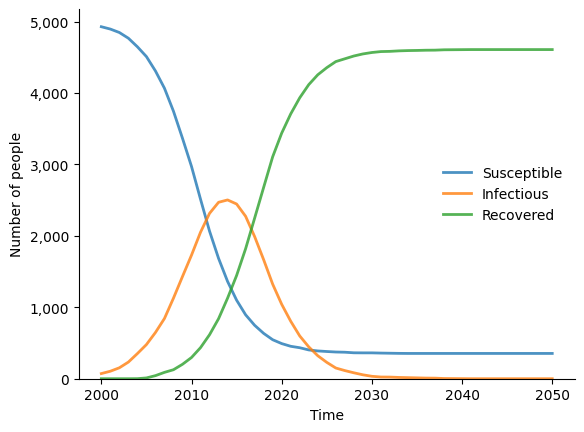

In [6]:
# slightly more realistic example
import starsim as ss

# Define the parameters
pars = dict(
    n_agents = 5_000,     # Number of agents to simulate
    networks = dict(      # Networks define how agents interact w/ each other
        type = 'random',  # Here, we use a 'random' network
        n_contacts = 10   # Each person has 10 contacts with other people
    ),
    diseases = dict(      # *Diseases* add detail on what diseases to model
        type = 'sir',     # Here, we're creating an SIR disease
        init_prev = 0.01, # Proportion of the population initially infected
        beta = 0.05,      # Probability of transmission between contacts
    )
)

# Make the sim, run and plot
sim = ss.Sim(pars)
sim.run()
sim.plot() # Plot all the sim results
sim.diseases.sir.plot() # Plot the standard SIR curves

Initializing sim with 5000 agents
  Running 2000.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 2010.0 (10/51) (0.03 s)  ••••———————————————— 22%
  Running 2020.0 (20/51) (0.05 s)  ••••••••———————————— 41%
  Running 2030.0 (30/51) (0.07 s)  ••••••••••••———————— 61%
  Running 2040.0 (40/51) (0.09 s)  ••••••••••••••••———— 80%
  Running 2050.0 (50/51) (0.11 s)  •••••••••••••••••••• 100%

Figure(800x600)


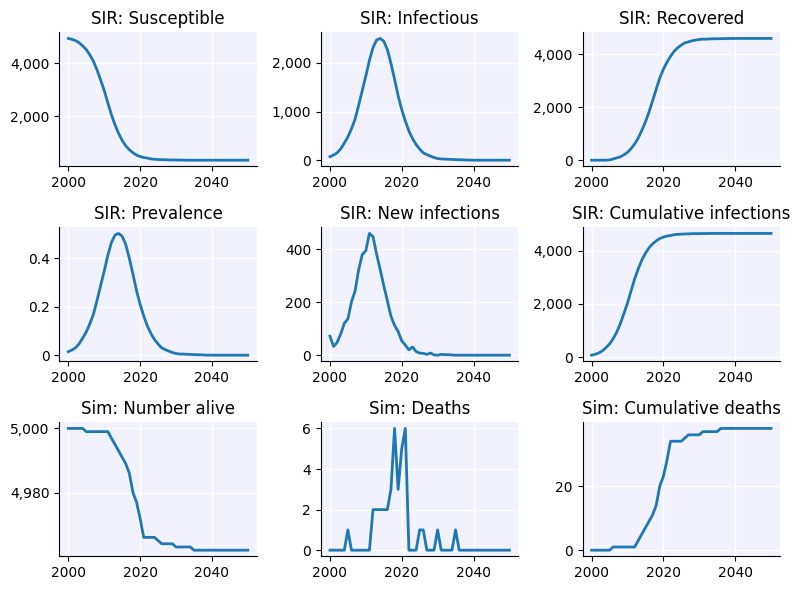

In [7]:
# build out same model using component templates
people = ss.People(n_agents=5_000)
network = ss.RandomNet(pars=dict(n_contacts=10))
sir = ss.SIR(init_prev=0.01, beta=0.05)
sim = ss.Sim(diseases=sir, people=people, networks=network)
sim.run()
sim.plot()

Initializing sim with 5000 agents
  Running 2000.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 2010.0 (10/51) (0.03 s)  ••••———————————————— 22%
  Running 2020.0 (20/51) (0.06 s)  ••••••••———————————— 41%
  Running 2030.0 (30/51) (0.08 s)  ••••••••••••———————— 61%
  Running 2040.0 (40/51) (0.10 s)  ••••••••••••••••———— 80%
  Running 2050.0 (50/51) (0.12 s)  •••••••••••••••••••• 100%

Figure(800x600)


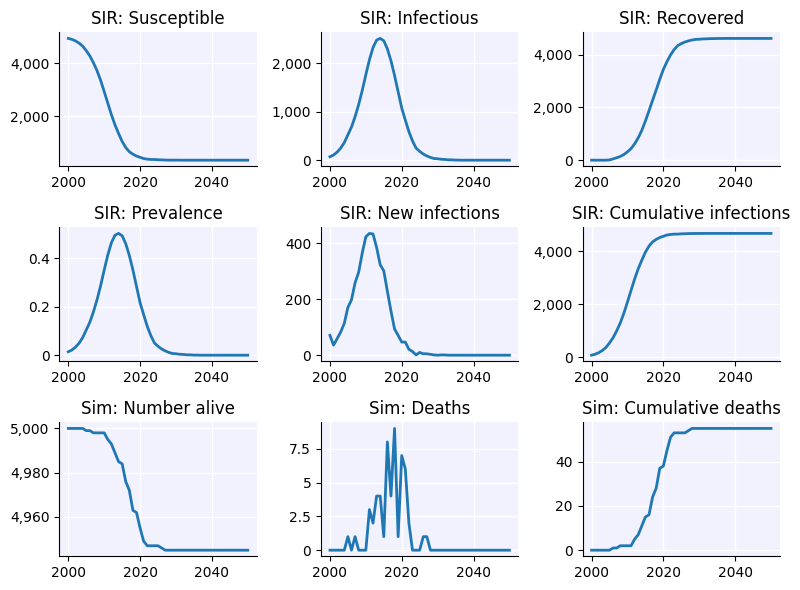

In [8]:
# change to a poisson network with same mean contacts
network = ss.RandomNet(pars={'n_contacts': ss.poisson(10)})
sim_p = ss.Sim(diseases=sir, people=people, networks=network)
sim_p.run()
sim_p.plot()

In [10]:
sim_p.results

Results(sim)
0. timevec: array(start=2000.0, stop=2050.0)
1. randomnet: Results(randomnet)
    1.0. timevec: array(start=2000.0, stop=2050.0)
    1.1. n_edges: Result(min=24570, mean=24842.6, max=25154)
2. sir: Results(sir)
    2.0. timevec: array(start=2000.0, stop=2050.0)
    2.1. n_susceptible: Result(min=333, mean=1342.94, max=4929)
    2.2. n_infected: Result(min=0, mean=597.039, max=2510)
    2.3. n_recovered: Result(min=0, mean=3023.29, max=4612)
    2.4. prevalence: Result(min=0, mean=0.11985, max=0.503511)
    2.5. new_infections: Result(min=0, mean=91.5098, max=436)
    2.6. cum_infections: Result(min=71, mean=3657.06, max=4667)
3. n_alive: Result(min=4945, mean=4963.27, max=5000)
4. new_deaths: Result(min=0, mean=1.07843, max=9)
5. cum_deaths: Result(min=0, mean=35.6471, max=55)

Initializing sim with 5000 agents
  Running 2020.01.01 ( 0/367) (0.00 s)  ———————————————————— 0%
  Running 2020.01.11 (10/367) (0.02 s)  ———————————————————— 3%
  Running 2020.01.21 (20/367) (0.05 s)  •——————————————————— 6%
  Running 2020.01.31 (30/367) (0.07 s)  •——————————————————— 8%
  Running 2020.02.10 (40/367) (0.09 s)  ••—————————————————— 11%
  Running 2020.02.20 (50/367) (0.11 s)  ••—————————————————— 14%
  Running 2020.03.01 (60/367) (0.13 s)  •••————————————————— 17%
  Running 2020.03.11 (70/367) (0.15 s)  •••————————————————— 19%
  Running 2020.03.21 (80/367) (0.17 s)  ••••———————————————— 22%
  Running 2020.03.31 (90/367) (0.19 s)  ••••———————————————— 25%
  Running 2020.04.10 (100/367) (0.21 s)  •••••——————————————— 28%
  Running 2020.04.20 (110/367) (0.24 s)  ••••••—————————————— 30%
  Running 2020.04.30 (120/367) (0.26 s)  ••••••—————————————— 33%
  Running 2020.05.10 (130/367) (0.28 s)  •••••••————————————— 36%
  Running 2020.05.20 (140/367) (0.30 s)  •••••••————————

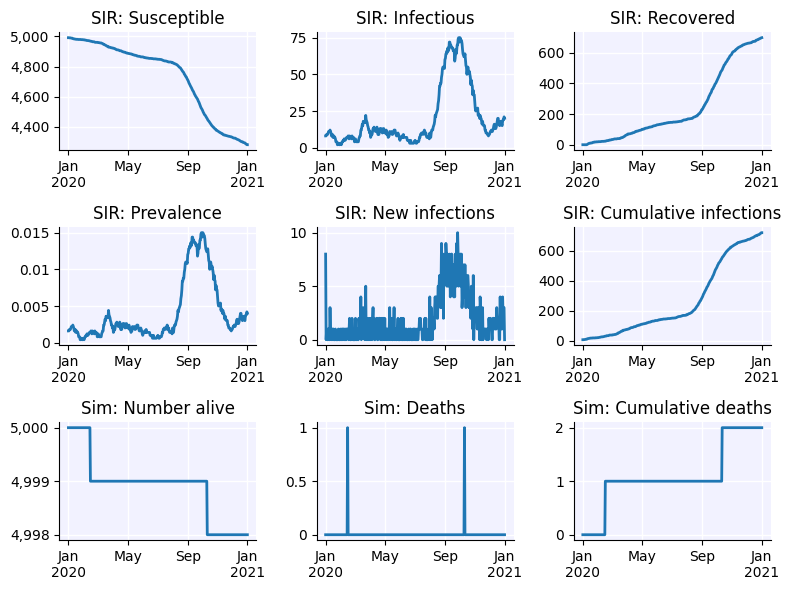

In [68]:
# default time starts in 1995 and timestep is in years
# move to daily starting in 2020
# R0 = 1.2  (beta*<K>*dur_inf)
# I DO NOT BELIEVE THE R0 is correct?!  I think this is much closer to 1 than 1.2, but I'm not sure why. 
people = ss.People(n_agents=5_000)
network = ss.RandomNet(pars={'n_contacts': ss.poisson(10)})
sir = ss.SIR(init_prev=0.001, beta=0.012, dur_inf=10)
sim = ss.Sim(diseases=sir, people=people, networks=network, start='2020-01-01', stop='2021-01-01', unit='day')
sim.run().plot()

In [69]:
# what happens when we output a sim as human readable?
sim.to_df().to_excel('getting_started_sim.xlsx')

Initializing sim with 5000 agents
  Running 1995.0 ( 0/51) (0.00 s)  ———————————————————— 2%
  Running 2005.0 (10/51) (0.06 s)  ••••———————————————— 22%
  Running 2015.0 (20/51) (0.13 s)  ••••••••———————————— 41%
  Running 2025.0 (30/51) (0.20 s)  ••••••••••••———————— 61%
  Running 2035.0 (40/51) (0.29 s)  ••••••••••••••••———— 80%
  Running 2045.0 (50/51) (0.38 s)  •••••••••••••••••••• 100%



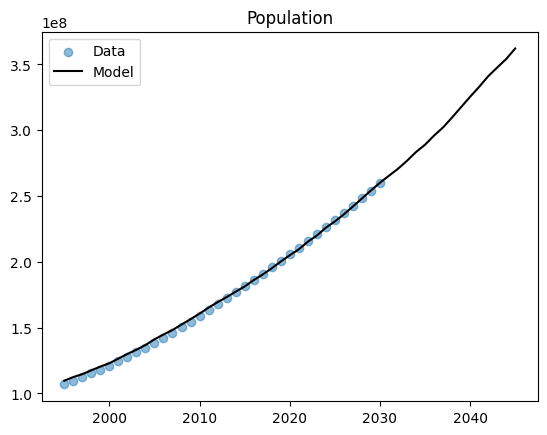

In [71]:
# much more realistic demographics
import starsim as ss
import pandas as pd
import matplotlib.pyplot as plt

# Read in age-specific fertility rates
fertility_rates = pd.read_csv('../tests/test_data/nigeria_asfr.csv')
pregnancy = ss.Pregnancy(pars={'fertility_rate': fertility_rates})

death_rates = pd.read_csv('../tests/test_data/nigeria_deaths.csv')
death = ss.Deaths(pars={'death_rate': death_rates, 'rate_units': 1})

demographics = [pregnancy, death]

# Make people using the distribution of the population by age/sex in 1995
n_agents = 5_000
nga_pop_1995 = 106819805  # Population of Nigeria in 1995, the year we will start the model
age_data = pd.read_csv('../tests/test_data/nigeria_age.csv')
ppl = ss.People(n_agents, age_data=age_data)

# Make the sim, run and plot
sim = ss.Sim(total_pop=nga_pop_1995, start=1995, people=ppl, demographics=demographics, networks='random', diseases='sir')
sim.run()

# Read in a file with the actual population size
nigeria_popsize = pd.read_csv('../tests/test_data/nigeria_popsize.csv')
data = nigeria_popsize[(nigeria_popsize.year >= 1995) & (nigeria_popsize.year <= 2030)]

# Plot the overall population size - simulated vs data
fig, ax = plt.subplots(1, 1)
res = sim.results
ax.scatter(data.year, data.n_alive, alpha=0.5, label='Data')
ax.plot(res.timevec, res.n_alive, color='k', label='Model')
ax.legend()
ax.set_title('Population')
plt.show()

In [81]:
# view into variables
pregnancy

[<class 'starsim.demographics.Pregnancy'>, <class 'starsim.demographics.Demographics'>, <class 'starsim.modules.Module'>, <class 'starsim.modules.Base'>, <class 'sciris.sc_printing.quickobj'>, <class 'sciris.sc_printing.prettyobj'>]
————————————————————————————————————————————————————————————————————————
Methods:
  _reconcile()            finish_step()           plot()                  
  copy()                  from_func()             set_metadata()          
  create()                init_post()             set_prognoses()         
  define_pars()           init_pre()              standardize_fertili...  
  define_results()        init_results()          start_step()            
  define_states()         init_time()             step()                  
  disp()                  make_embryos()          to_json()               
  do_step()               make_fertility_prob...  update_pars()           
  finalize()              make_pregnancies()      update_results()        
  finalize